# ES3A vs ES3B Benchmark
Confronto prestazionale tra versione base (es3A.c) e versione con memoization (es3B.c).

Il notebook compila i sorgenti, genera input validi e misura i tempi con mediana su piu run.

In [8]:
import subprocess
from pathlib import Path

root = Path('.').resolve()
src_a = root / 'es3A.c'
src_b = root / 'es3B.c'
exe_a = root / 'es3A'
exe_b = root / 'es3B'

if not src_a.exists() or not src_b.exists():
    raise FileNotFoundError('Servono es3A.c e es3B.c nella stessa cartella del notebook')

print('Compilazione in corso...')
subprocess.run(['gcc', '-O2', '-w', str(src_a), '-o', str(exe_a)], check=True)
subprocess.run(['gcc', '-O2', '-w', str(src_b), '-o', str(exe_b)], check=True)
print('Compilazione completata')

Compilazione in corso...
Compilazione completata


In [9]:
import random
import time
import statistics

rng = random.Random(42)

def gen_safe_instance(T, N):
    # Family semplice e sempre fattibile: tutte le pause durano 1 minuto.
    pauses = [1] * N
    return f'{T} {N}\n' + ' '.join(map(str, pauses)) + '\n'

def run_once(exe_path, input_data):
    t0 = time.perf_counter()
    p = subprocess.Popen(
        [str(exe_path)],
        stdin=subprocess.PIPE,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        text=True
    )
    p.communicate(input_data)
    return time.perf_counter() - t0

def run_and_capture(exe_path, input_data):
    p = subprocess.Popen(
        [str(exe_path)],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    out, _ = p.communicate(input_data)
    return out.strip()

def parse_instance(input_data):
    lines = [ln.strip() for ln in input_data.strip().splitlines() if ln.strip()]
    T, N = map(int, lines[0].split())
    pauses = list(map(int, lines[1].split()))
    return T, N, pauses

def validate_solution(input_data, output_data):
    T, N, pauses = parse_instance(input_data)

    if output_data.lower().startswith('no possible sol'):
        return False

    toks = output_data.split()
    if len(toks) != N:
        return False
    try:
        starts = list(map(int, toks))
    except ValueError:
        return False

    for i in range(N):
        s = starts[i]
        k = pauses[i]
        if s < 0 or s + k > T:
            return False

    for t in range(T):
        in_pause = 0
        for i in range(N):
            if starts[i] <= t < starts[i] + pauses[i]:
                in_pause += 1
        if in_pause > 2:
            return False

    return True

def measure(exe_path, input_data, repeats=2, warmup=1):
    for _ in range(warmup):
        run_once(exe_path, input_data)
    samples = [run_once(exe_path, input_data) for _ in range(repeats)]
    return statistics.median(samples)

In [ ]:
# Benchmark su 20 test possibili fissati
# Tengo le istanze fattibili e crescenti, cosi il grafico viene piu leggibile.
tests = [
    (1,  6, 3, [1, 1, 1]),
    (2,  7, 4, [1, 1, 1, 1]),
    (3,  8, 5, [1, 1, 1, 1, 1]),
    (4,  9, 6, [1, 1, 1, 1, 1, 1]),
    (5, 10, 7, [1, 1, 1, 1, 1, 1, 1]),
    (6, 11, 8, [1, 1, 1, 1, 1, 1, 1, 1]),
    (7, 12, 9, [1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (8, 13, 9, [1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (9, 14, 10, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (10, 15, 10, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (11, 16, 11, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (12, 17, 11, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (13, 18, 12, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (14, 19, 12, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (15, 20, 13, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (16, 21, 13, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (17, 22, 14, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (18, 23, 14, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (19, 24, 15, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
    (20, 25, 15, [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
]

input_sizes = []
times_a = []
times_b = []

print('Check correttezza + benchmark su 20 test fissati...')
for idx, T, N, pauses in tests:
    data = f'{T} {N}\n' + ' '.join(map(str, pauses)) + '\n'

    out_a = run_and_capture(exe_a, data)
    out_b = run_and_capture(exe_b, data)
    ok_a = validate_solution(data, out_a)
    ok_b = validate_solution(data, out_b)

    if not ok_a or not ok_b:
        print(f'TEST {idx} | output non valido -> A:{ok_a} B:{ok_b}')
        raise RuntimeError('Benchmark fermato: almeno una soluzione non rispetta i vincoli')

    ta = measure(exe_a, data, repeats=3, warmup=1)
    tb = measure(exe_b, data, repeats=3, warmup=1)
    input_sizes.append(N)
    times_a.append(ta)
    times_b.append(tb)
    print(f'TEST {idx}: T={T}, N={N} | es3A={ta*1000:8.3f} ms | es3B={tb*1000:8.3f} ms | speedup={ta/max(tb, 1e-12):6.2f}x')

print('Benchmark completato')

Check correttezza + benchmark su 20 test fissati...
TEST 1: T=6, N=3 | es3A=  10.147 ms | es3B=   9.813 ms | speedup=  1.03x
TEST 2: T=7, N=4 | es3A=   8.143 ms | es3B=   8.933 ms | speedup=  0.91x
TEST 3: T=8, N=5 | es3A=  12.236 ms | es3B=  12.403 ms | speedup=  0.99x
TEST 4: T=9, N=6 | es3A=   9.744 ms | es3B=   7.468 ms | speedup=  1.30x
TEST 5: T=10, N=7 | es3A=   8.779 ms | es3B=   9.167 ms | speedup=  0.96x
TEST 6: T=11, N=8 | es3A=  23.050 ms | es3B=  10.862 ms | speedup=  2.12x
TEST 7: T=12, N=9 | es3A=  41.588 ms | es3B=   7.032 ms | speedup=  5.91x
TEST 8: T=13, N=9 | es3A=  45.980 ms | es3B=   9.345 ms | speedup=  4.92x
TEST 9: T=14, N=10 | es3A= 413.193 ms | es3B=   7.460 ms | speedup= 55.39x
TEST 10: T=15, N=10 | es3A= 401.566 ms | es3B=   9.105 ms | speedup= 44.11x
TEST 11: T=16, N=11 | es3A=3464.161 ms | es3B=   9.284 ms | speedup=373.12x
TEST 12: T=17, N=11 | es3A=3407.007 ms | es3B=   9.158 ms | speedup=372.04x
TEST 13: T=18, N=12 | es3A=46417.626 ms | es3B=   8.757 m

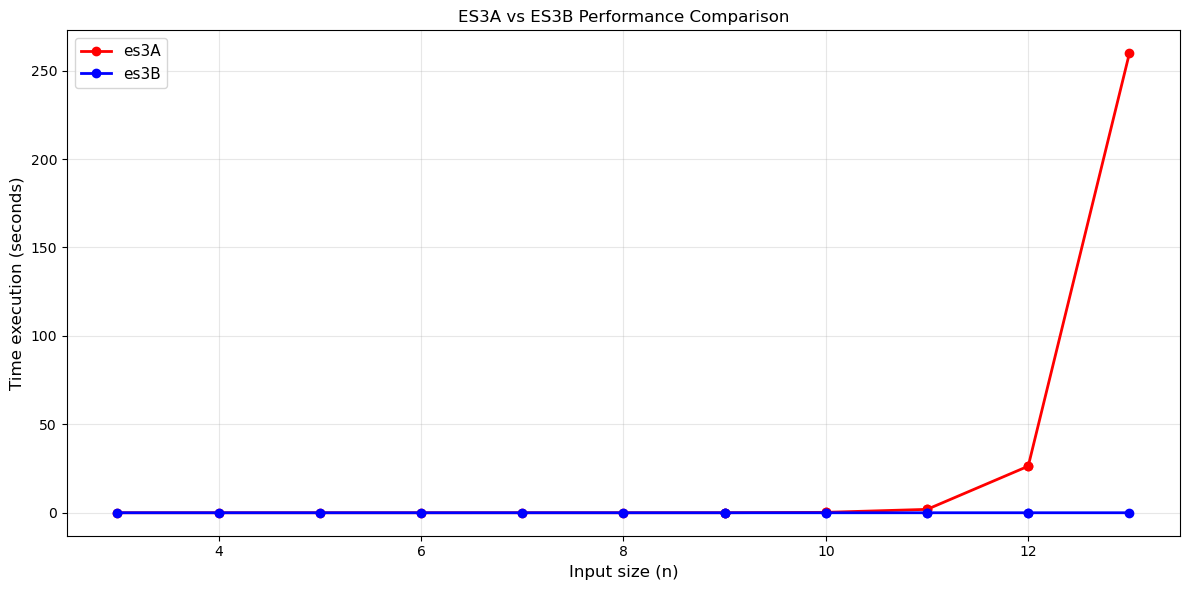

In [ ]:
import matplotlib.pyplot as plt

# Grafico performance: input size vs execution time
plt.figure(figsize=(12, 6))
plt.plot(input_sizes, times_a, label='es3A', color='red', marker='o', linewidth=2)
plt.plot(input_sizes, times_b, label='es3B', color='blue', marker='o', linewidth=2)
plt.xlabel('Input size (n)', fontsize=12)
plt.ylabel('Time execution (seconds)', fontsize=12)
plt.title('ES3A vs ES3B Performance Comparison')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Test ESAGERATO GIGANTE su es3B
import subprocess
import time

def gen_test_massive_es3(T, N):
    """Genera input per test gigante es3."""
    pauses = [1] * N
    return f'{T} {N}\n' + ' '.join(map(str, pauses)) + '\n'

print("=== TEST ESAGERATO GIGANTE SU ES3B ===")
huge_test_params = [
    (30_000, 15_000),
    (60_000, 30_000),
    (90_000, 45_000),
    (120_000, 60_000),
    (150_000, 75_000),
]

for T, N in huge_test_params:
    data = gen_test_massive_es3(T, N)
    
    start = time.time()
    try:
        p = subprocess.run(['./es3B'], input=data.encode(), capture_output=True, timeout=600)
        elapsed = time.time() - start
        print(f"T={T:>6}, N={N:>6} -> {elapsed:.3f} s, returncode={p.returncode}")
    except subprocess.TimeoutExpired:
        print(f"T={T:>6}, N={N:>6} -> TIMEOUT after 600 s")

=== TEST ESAGERATO GIGANTE SU ES3B ===
T= 10000, N=  5000 -> 0.067 s, returncode=0
T= 20000, N= 10000 -> 0.125 s, returncode=0
T= 30000, N= 15000 -> 0.267 s, returncode=0
T= 40000, N= 20000 -> 0.430 s, returncode=0
T= 50000, N= 25000 -> 0.668 s, returncode=0
